We will demostrate below how one can construct the waveform at *any* total mass $M$ at a given $q$ from a single waveform at that $q$ at some total mass.
This phenomenal property is the result of 
1. non-existence of any inherent mass scale in GR
2. "perfect" nature of black holes- black holes are *completely* characterized by their mass, spin and charge. What this means is that the above assertion of total mass entering in trivial fashion in equations won't necessarily be true for, say, a neutron star because it might be possible that for a higher toatal mass $M$, the NS may have a different nuclear composition, changing the EOS and hence the pressure of the core, which in turn will affect the energy-momentum tensor and hence the dynamical equations.

Thus, one can work in dimensionless units by choosing the mass scale as $M$ only and hence making the dimensionless version of the problem completely devoid of $M$ (this is called *scaling $M$ out*).Therefore, the dynamics of any BBH system depends non-trivially only on the ratios of various quantities like $\displaystyle \frac{m_1}{m_2}$, etc. and depends trivially on total mass $M$ in the form of simple scaling relations that one obtains when one switches from the non-dimensionalized to the dimensionful version of the dynamical equations.

$$t_0 = \frac{GM}{c^3}$$
$$l_0 = \frac{GM}{c^2}$$

In [1]:
import pycbc.waveform as wf
import pycbc
import matplotlib.pyplot as plt
import time
from astropy.constants import GM_sun, c

q = 10
M = [10, 40, 60]

l0 = GM_sun*M/(c*c)
t0 = GM_sun*M/(c*c*c)

h_Plus = []
h_Cross =[]

Time = []

for i in range(0,len(M)):

    t1 = time.time()
    
    h_plus, h_cross = wf.get_td_waveform(approximant = 'SEOBNRv1', mass1 = q*M[i]/(1+q), mass2 = M[i]/(1+q), f_lower = 0.002/t0[i].value, delta_t = 1/16384)
    #h_plus, h_cross = wf.get_td_waveform(approximant = 'SEOBNRv1', mass1 = q*M[i]/(1+q), mass2 = M[i]/(1+q), f_lower = 100, delta_t = 1/16384)
    h_Plus.append(h_plus)
    h_Cross.append(h_cross)
    
    t2 = time.time()
    Time.append(t2 - t1)
    print ('Iteration complete')
    
plt.plot(M, Time, 'x')
plt.title('Time taken to generate the waveforms w.r.t. $M$ for fixed $q$ ')
plt.xlabel('M $(M_\odot)$)')
plt.ylabel('Time taken (s)')
plt.grid()

Iteration complete
Iteration complete
Iteration complete


In [1]:
t0

NameError: name 't0' is not defined

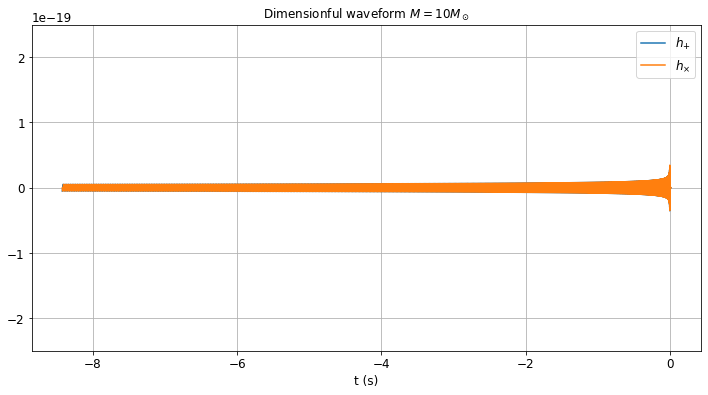

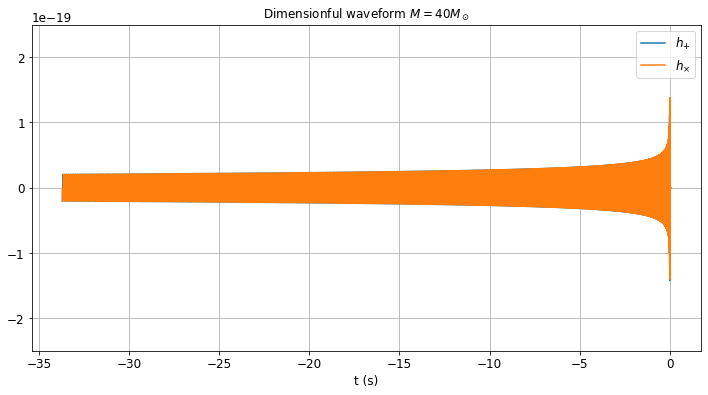

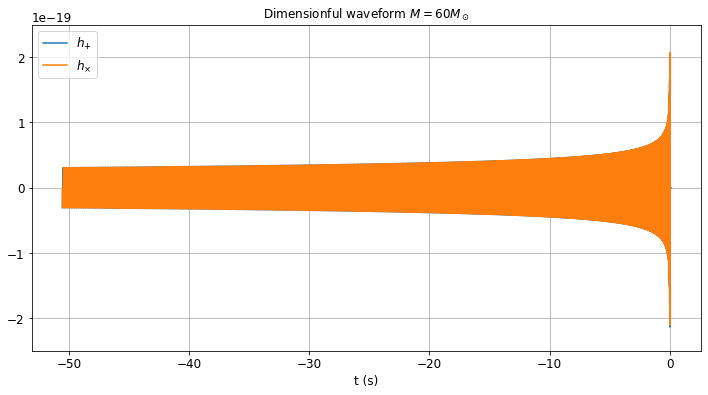

In [4]:
%matplotlib inline

#xmin, xmax, ymin, ymax = -20, 0.5, -6.5e-19, 6.25e-19
xmin, xmax, ymin, ymax = -1., 0.1, -2.5e-19, 2.5e-19

plt.figure(figsize = (12, 6))
plt.title(f'Dimensionful waveform $ M = {M[0]} M_\odot$')
plt.plot(h_Plus[0].sample_times, h_Plus[0], label = '$h_{+}$')
plt.plot(h_Cross[0].sample_times, h_Cross[0], label = r'$h_{\times}$')
plt.xlabel('t (s)')
#plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.legend()
plt.grid()

plt.figure(figsize = (12, 6))
plt.title(f'Dimensionful waveform $ M = {M[1]} M_\odot$')
plt.plot(h_Plus[1].sample_times, h_Plus[1], label = '$h_{+}$')
plt.plot(h_Cross[1].sample_times, h_Cross[1], label = r'$h_{\times}$')
plt.xlabel('t (s)')
#plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.legend()
plt.grid()

plt.figure(figsize = (12, 6))
plt.title(f'Dimensionful waveform $ M = {M[2]} M_\odot$')
plt.plot(h_Plus[2].sample_times, h_Plus[2], label = '$h_{+}$')
plt.plot(h_Cross[2].sample_times, h_Cross[2], label = r'$h_{\times}$')
plt.xlabel('t (s)')
#plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.legend()
plt.grid()

A constant *dimensionless* low frequency cutoff was chosen for these waveforms, $M f_{\mathrm{low}} = 0.002$, which means the *dimensionful* low frequency cutoff is different (lower for higher $M$) for different waveforms. From above plots, one can easily see that $$T \propto M$$ $$h \propto M$$

This means that by suitable scaling of x-axis (i.e. time) and y-axis (i.e. strain), one can reduce all these plots to a *single, "dimensionless" plot*. This is demonstrated below. Equipped with this knowledge of mass-scaling, one can then create a *single, "dimensionless" waveform* and can reverse-engineer the waveforms at any total mass $M$ by re-inserting the appropriate mass-scaling in that "dimensionless" waveform.

(However, there is one thing which is *not* similar in these waveforms. Since these waveforms were generated at constant *dimensionful* sampling rate of $2^{14}$Hz, i.e. $\Delta t = 2^{-14}$s is constant in dimensionful units, and $T \propto M$, therefore the waveform with higher $M$ is composed of *more* data points.) 

<IPython.core.display.Javascript object>


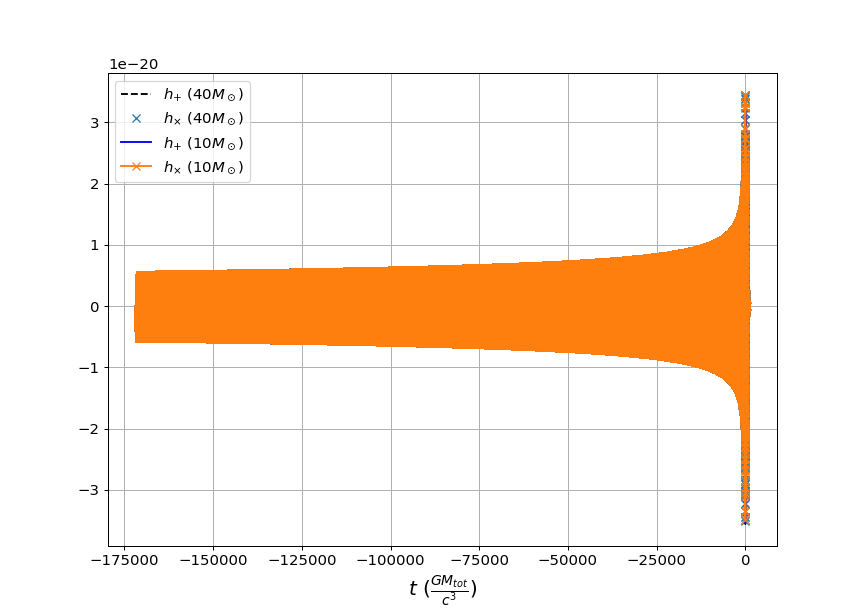

In [5]:
%matplotlib notebook

plt.figure(figsize = (12, 6))
plt.plot(h_Plus[1].sample_times/t0[1], h_Plus[1]*M[0]/M[1], label = f'$h_{{+}} \ ({M[1]} M_\odot)$', ls = '--', color = 'black')
#plt.plot(h_Cross[1].sample_times/t0[1], h_Cross[1]/2, label = r'$h_{\times}$', ls = '--')
plt.plot(h_Cross[1].sample_times/t0[1], h_Cross[1]*M[0]/M[1], 'x', label = f'$h_{{\\times}} \ ({M[1]} M_\odot)$')
plt.xlabel(r'$t\ (\frac{G M_{tot}}{c^3})$', fontsize = 16)
#plt.legend()
#plt.grid()

#plt.figure(figsize = (12, 6))
plt.plot(h_Plus[0].sample_times/t0[0], h_Plus[0], label = f'$h_{{+}} \ ({M[0]} M_\odot)$', color = 'blue')
#plt.plot(h_Cross[0].sample_times/t0[0], h_Cross[0], label = r'$h_{\times}$')
plt.plot(h_Cross[0].sample_times/t0[0], h_Cross[0], marker = 'x', ls = '-', label = f'$h_{{\\times}} \ ({M[0]} M_\odot)$')
plt.xlabel(r'$t\ (\frac{G M_{tot}}{c^3})$', fontsize = 16)
plt.legend()
plt.grid()

Thus, $T \propto M$ or $N \propto M$, which is explicitly checked below.

In [11]:
len(h_Plus[1])/len(h_Plus[0])

4.000007229821568

In [12]:
h_Plus[1].duration/h_Plus[0].duration

4.000007229821568

In [14]:
h_Plus[1].duration*t0[0]/(h_Plus[0].duration*t0[1])

<Quantity 1.00000181>